### Project 3: Unsupervised Learning - Customer Segmentation
DecodeLabs Industrial Training Kit | Batch 2026

Dataset: Customer Personality Analysis (Kaggle)
Link: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis
File: marketing_campaign.csv

Pipeline: SCALE -> COMPRESS (PCA) -> CLUSTER (K-Means) -> TRANSLATE (Personas)

In [13]:
import os
print(os.getcwd())

d:\internship


### Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [15]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")

print("Dataset Shape:", df.shape)
print(df.head())
print(df.info())

Dataset Shape: (2240, 29)
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  C

### Data Cleaning

In [16]:
# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# fill missing values with median
df["Income"] = df["Income"].fillna(df["Income"].median())

# Calculate age of customer (Year_Birth)
df["Age"] = 2026 - df["Year_Birth"]

# Customer registration period(from Dt_Customer)
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True, errors="coerce")
df["Enrollment_Days"] = (df["Dt_Customer"].max() - df["Dt_Customer"]).dt.days

# Total spending (sum of all product categories) - new useful feature
spend_cols = ["MntWines", "MntFruits", "MntMeatProducts",
              "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df["Total_Spending"] = df[spend_cols].sum(axis=1)

# Total children in house
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

# Remove Outliers(Age > 100 && Income > 600000 are wrong data)
df = df[(df["Age"] < 100) & (df["Income"] < 600000)]


Missing Values:
 ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


### Feature Selection

In [17]:
features = [
    "Age", "Income", "Recency", "MntWines", "MntFruits",
    "MntMeatProducts", "MntFishProducts", "MntSweetProducts",
    "MntGoldProds", "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth",
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4",
    "AcceptedCmp5", "Complain", "Total_Spending", "Total_Children",
    "Enrollment_Days"
]

X = df[features].copy()
X.fillna(X.median(), inplace=True)

print(f"\nTotal Features Used for Clustering: {len(features)}")


Total Features Used for Clustering: 23


### SCALE - Standardization

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### COMPRESS - PCA (Dimensionality Reduction)

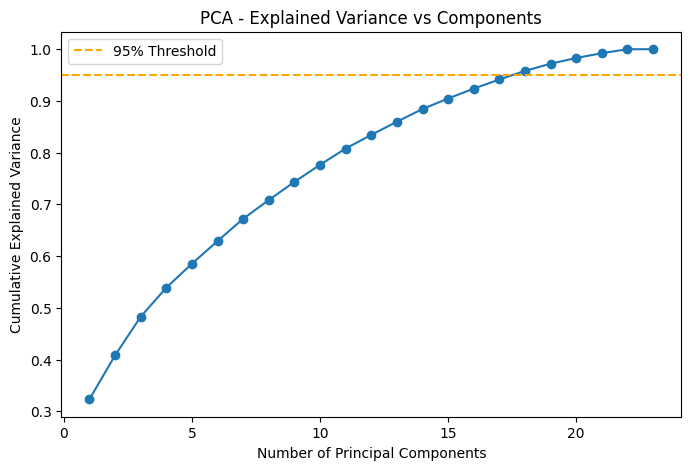


Components needed for 95% variance: 18
Variance explained by 3 components: 48.28%


In [19]:
# First of all check how many components retain 95 variance
pca_full = PCA().fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.95, color="orange", linestyle="--", label="95% Threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance vs Components")
plt.legend()
plt.savefig("pca_variance.png", dpi=100, bbox_inches="tight")
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nComponents needed for 95% variance: {n_components_95}")

# PCA - 3 components(for 2D/3D visualization)
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Variance explained by 3 components: {pca.explained_variance_ratio_.sum():.2%}")

### CLUSTER - Optimal K (Elbow + Silhouette)

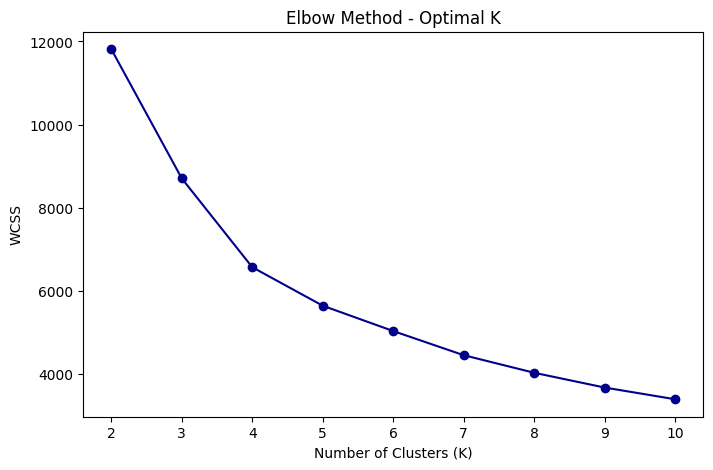

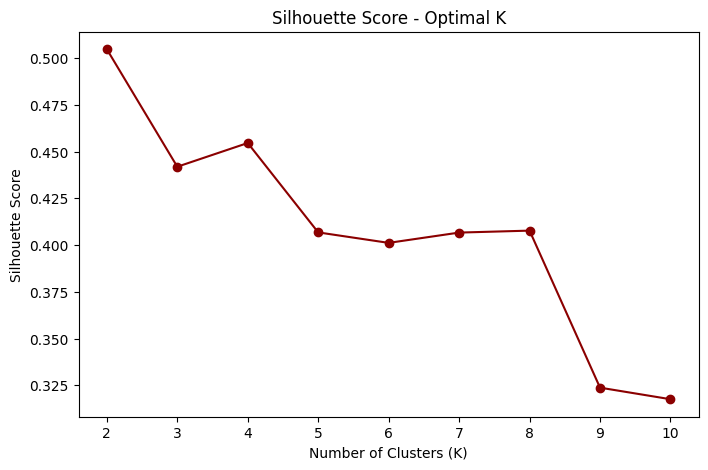


Best K (Highest Silhouette Score): 2
Silhouette Scores: {2: np.float64(0.505), 3: np.float64(0.442), 4: np.float64(0.455), 5: np.float64(0.407), 6: np.float64(0.401), 7: np.float64(0.407), 8: np.float64(0.408), 9: np.float64(0.324), 10: np.float64(0.318)}


In [20]:
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

# Elbow Method Graph
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker="o", color="darkblue")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method - Optimal K")
plt.savefig("elbow_method.png", dpi=100, bbox_inches="tight")
plt.show()

# Silhouette Score Graph
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o", color="darkred")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Optimal K")
plt.savefig("silhouette_scores.png", dpi=100, bbox_inches="tight")
plt.show()

best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nBest K (Highest Silhouette Score): {best_k}")
print("Silhouette Scores:", dict(zip(K_range, [round(s, 3) for s in silhouette_scores])))

### Final K-Means Model (use best_k)

In [21]:
# NOTE: best_k willl choosed automatically , but it can be choosen manually 
#  By seeing elbow graph best_k=4
kmeans_final = KMeans(n_clusters=best_k, init="k-means++", random_state=42, n_init=10)
df["Cluster"] = kmeans_final.fit_predict(X_pca)

### 3D Visualization of Clusters

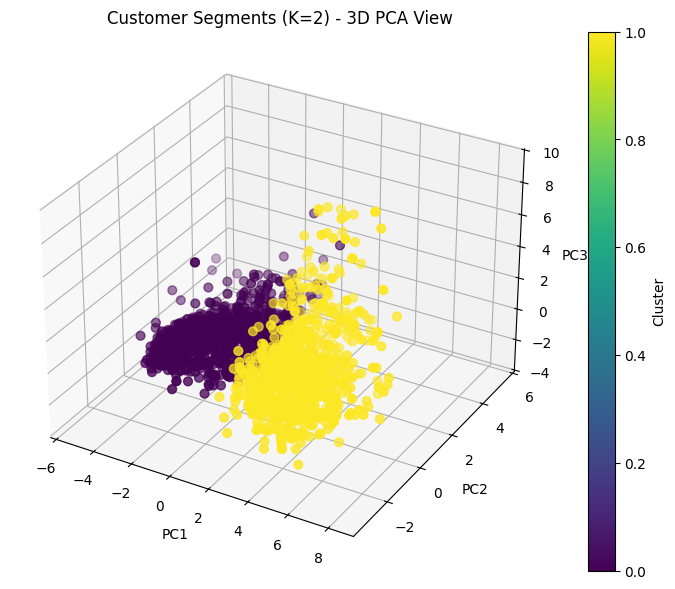

In [22]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                      c=df["Cluster"], cmap="viridis", s=40)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title(f"Customer Segments (K={best_k}) - 3D PCA View")
plt.colorbar(scatter, label="Cluster")
plt.savefig("clusters_3d.png", dpi=100, bbox_inches="tight")
plt.show()

### TRANSLATE - Business Personas

In [23]:
persona_summary = df.groupby("Cluster")[
    ["Age", "Income", "Total_Spending", "Recency",
     "NumWebPurchases", "NumStorePurchases", "Total_Children"]
].mean().round(1)

persona_summary["Count"] = df["Cluster"].value_counts().sort_index()

print("\n===================== PERSONA MATRIX =====================")
print(persona_summary)
print("============================================================")

# Saving the persona in csv
persona_summary.to_csv("cluster_personas.csv")

# Suggest simple label for each cluster 
def label_cluster(row):
    if row["Income"] > df["Income"].median() and row["Total_Spending"] > df["Total_Spending"].median():
        return "High-Value Loyal Customers"
    elif row["Income"] > df["Income"].median() and row["Total_Spending"] <= df["Total_Spending"].median():
        return "Affluent but Low Engagement"
    elif row["Income"] <= df["Income"].median() and row["Total_Spending"] > df["Total_Spending"].median():
        return "Budget-Conscious Enthusiasts"
    else:
        return "Low Engagement / At-Risk"

persona_summary["Persona_Label"] = persona_summary.apply(label_cluster, axis=1)
print("\nFinal Persona Labels:\n", persona_summary[["Persona_Label"]])

persona_summary.to_csv("cluster_personas_labeled.csv")

print("\n Project 3 Complete! Saare graphs (.png) aur persona CSVs current folder me save ho gaye hain.")


===================== PERSONA MATRIX =====================
          Age   Income  Total_Spending  Recency  NumWebPurchases  \
Cluster                                                            
0        56.1  39574.1           198.6     48.7              3.1   
1        58.8  71984.4          1265.2     49.8              5.7   

         NumStorePurchases  Total_Children  Count  
Cluster                                            
0                      4.1             1.2   1382  
1                      8.6             0.5    854  

Final Persona Labels:
                       Persona_Label
Cluster                            
0          Low Engagement / At-Risk
1        High-Value Loyal Customers

 Project 3 Complete! Saare graphs (.png) aur persona CSVs current folder me save ho gaye hain.
